# Estado da Arte — Levantamento Bibliográfico

---

**Instituto Federal de Goiás – IFG**
**Programa de Pós-Graduação em Educação Profissional e Tecnológica – ProfEPT**
**Mestrado Profissional em Educação Profissional e Tecnológica**

**Pesquisador:** Marco Antônio Queiroz
**Orientadora:** Profa. Dra. Claudia Helena dos Santos Araujo
**Linha de pesquisa:** Práticas Educativas em Educação Profissional e Tecnológica (EPT)
**Anápolis – GO | 2026**

---

**PRÁTICAS COLABORATIVAS DE MEDIAÇÃO PEDAGÓGICA E LINGUÍSTICA ENTRE PROFESSORES E INTÉRPRETES NA EDUCAÇÃO PROFISSIONAL E TECNOLÓGICA: PROPOSIÇÃO DE UM AMBIENTE BILÍNGUE DE MEDIAÇÃO CONCEITUAL (PORTUGUÊS/LIBRAS)**

---

## Nota metodológica

Este notebook documenta o **Estado da Arte** da pesquisa, seguindo a abordagem proposta por Ferreira (2002) e Romanowski e Ens (2006), que caracterizam esse tipo de produção acadêmica como um inventário descritivo e analítico da produção científica sobre determinada temática, com o objetivo de identificar o que já foi investigado, como foi investigado e quais lacunas permanecem abertas.

O processo de levantamento seguiu protocolo sistemático de busca, triagem e seleção, documentado neste notebook em quatro etapas:

1. **Identificação** — busca nas bases de dados com estratégias por eixo temático
2. **Triagem** — aplicação dos critérios de inclusão e exclusão por tipo e período
3. **Elegibilidade temática** — leitura de títulos e resumos com base nos critérios temáticos
4. **Corpus final** — conjunto de trabalhos analisados por eixo

> **Referências metodológicas:**
> FERREIRA, N. S. A. As pesquisas denominadas "estado da arte". *Educação & Sociedade*, Campinas, v. 23, n. 79, p. 257–272, ago. 2002.
> ROMANOWSKI, J. P.; ENS, R. T. As pesquisas denominadas do tipo "estado da arte" em educação. *Diálogo Educacional*, Curitiba, v. 6, n. 19, p. 37–50, 2006.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
ACCENT  = '#1a5276'
PAL     = ['#2980b9','#e74c3c','#27ae60','#9b59b6','#f39c12','#95a5a6']
EIXOS   = ['Eixo 1','Eixo 2','Eixo 3','Eixo 4','Eixo 5']
EIXO_FULL = {
    'Eixo 1': 'Eixo 1 — Educação de surdos + mediação',
    'Eixo 2': 'Eixo 2 — Educação de surdos + professor/intérprete',
    'Eixo 3': 'Eixo 3 — Educação de surdos + colaboração',
    'Eixo 4': 'Eixo 4 — Educação de surdos + tecnologias',
    'Eixo 5': 'Eixo 5 — Educação Profissional e Tecnológica',
}

# ── Carregamento ─────────────────────────────────────────────────────────────
conn = sqlite3.connect('data/data.sqlite')
df_raw = pd.read_sql_query("SELECT * FROM pesquisa", conn)
conn.close()

df_raw['Ano'] = pd.to_numeric(df_raw['Ano'], errors='coerce')

# Normalizar tipos
TIPO_MAP = {
    'masterThesis': 'Dissertação',
    'Dissertação (Mestrado)': 'Dissertação',
    'Produto Educacional / Dissertação': 'Dissertação',
    'doctoralThesis': 'Tese',
    'Artigo Científico': 'Artigo',
    'Artigo (Anais de Evento Científico)': 'Artigo',
}
df_raw['Tipo'] = df_raw['Tipo de Material'].map(
    lambda x: TIPO_MAP.get(str(x).strip(), str(x).strip()) if pd.notna(x) else ''
)

print(f"Base carregada: {len(df_raw):,} registros | {len(df_raw.columns)} colunas")


Base carregada: 2,618 registros | 59 colunas


## 1. Protocolo de Busca

### 1.1 Bases de dados, período e descritores

O levantamento foi realizado nas bases **BDTD (IBICT)** e **Catálogo de Teses e Dissertações da CAPES**, abrangendo produções do período **2020–2026**. Esse recorte temporal corresponde à consolidação mais recente da produção acadêmica sobre os temas investigados e ao período de maior crescimento das dissertações sobre educação de surdos na Pós-Graduação brasileira.

A estratégia de busca foi organizada em **cinco eixos temáticos** que estruturam o estado da arte conforme os objetivos da pesquisa. Para cada eixo foram elaborados descritores específicos, combinados com operadores booleanos (AND, OR) e truncamentos (*), de forma a garantir abrangência sem perda de especificidade.

### 1.2 Eixos temáticos e justificativa

| Eixo | Foco temático | Justificativa para a pesquisa |
|------|--------------|-------------------------------|
| **Eixo 1** | Educação de surdos + mediação | Base conceitual da mediação pedagógica e linguística (Vigotski; Saviani) |
| **Eixo 2** | Educação de surdos + professor + intérprete | **Núcleo central** — relação professor-intérprete em contextos bilíngues |
| **Eixo 3** | Educação de surdos + colaboração | Dimensão colaborativa: coplanejamento e organização conjunta |
| **Eixo 4** | Educação de surdos + tecnologias | Fundamentação do Produto Educacional (PE) digital bilíngue |
| **Eixo 5** | Educação Profissional e Tecnológica | Contexto específico da investigação — EPT e Institutos Federais |


In [2]:
# Estratégias de busca utilizadas por eixo
ESTRATEGIAS = {
    'Eixo 1': (
        '(surd* OR Libras OR "Língua Brasileira de Sinais") '
        'AND (mediação OR "mediação pedagógica" OR "mediação linguística" '
        'OR "mediação conceitual" OR "transposição didática")'
    ),
    'Eixo 2': (
        '(professor OR docente OR educador OR TILS OR intérprete OR "intérprete de Libras") '
        'AND (surdo OR surdez OR Libras OR "educação bilíngue" OR "comunidade surda" OR "estudante surdo") '
        'AND ("mediação pedagógica" OR "mediação linguística" OR "circulação de conhecimentos" '
        'OR "construção compartilhada de significados" OR "mediação conceitual" '
        'OR "interação pedagógica" OR "ensino colaborativo" OR colaboração '
        'OR codocência OR coplanejamento OR "formação conceitual")'
    ),
    'Eixo 3': (
        '(surdo OR surdez OR Libras OR "Língua Brasileira de Sinais") '
        'AND (colaboração OR "ensino colaborativo" OR codocência OR coplanejamento '
        'OR "trabalho colaborativo" OR "prática colaborativa")'
    ),
    'Eixo 4': (
        '(surdo OR surdez OR Libras OR "Língua Brasileira de Sinais") '
        'AND (software OR aplicativo OR plataforma OR "ambiente digital" '
        'OR "tecnologia educacional" OR "recurso digital" OR hipermídia '
        'OR PWA OR "aplicativo web" OR "tecnologia assistiva")'
    ),
    'Eixo 5': (
        '(surdo OR surdez OR Libras OR "intérprete") '
        'AND ("educação profissional" OR EPT OR "ensino técnico" '
        'OR "Instituto Federal" OR IFET OR "rede federal")'
    ),
}

print("ESTRATÉGIAS DE BUSCA POR EIXO TEMÁTICO")
print("=" * 70)
for eixo, descr in ESTRATEGIAS.items():
    full = EIXO_FULL[eixo]
    print(f"\n{full}")
    print("-" * len(full))
    # Quebrar em linhas para leitura
    palavras = descr.split()
    linha, linhas = "", []
    for p in palavras:
        if len(linha) + len(p) + 1 > 78:
            linhas.append(linha)
            linha = p
        else:
            linha = (linha + " " + p).strip()
    if linha: linhas.append(linha)
    print("  " + "\n  ".join(linhas))


ESTRATÉGIAS DE BUSCA POR EIXO TEMÁTICO

Eixo 1 — Educação de surdos + mediação
--------------------------------------
  (surd* OR Libras OR "Língua Brasileira de Sinais") AND (mediação OR "mediação
  pedagógica" OR "mediação linguística" OR "mediação conceitual" OR
  "transposição didática")

Eixo 2 — Educação de surdos + professor/intérprete
--------------------------------------------------
  (professor OR docente OR educador OR TILS OR intérprete OR "intérprete de
  Libras") AND (surdo OR surdez OR Libras OR "educação bilíngue" OR "comunidade
  surda" OR "estudante surdo") AND ("mediação pedagógica" OR "mediação
  linguística" OR "circulação de conhecimentos" OR "construção compartilhada de
  significados" OR "mediação conceitual" OR "interação pedagógica" OR "ensino
  colaborativo" OR colaboração OR codocência OR coplanejamento OR "formação
  conceitual")

Eixo 3 — Educação de surdos + colaboração
-----------------------------------------
  (surdo OR surdez OR Libras OR "Língua Bra

## 2. Critérios de Inclusão e Exclusão

Os critérios foram definidos previamente ao processo de busca, orientados pelo problema e pelos objetivos da pesquisa, e aplicados em duas etapas: a primeira sobre tipo de material e período (triagem formal); a segunda sobre pertinência temática, por meio da leitura de títulos e resumos (triagem temática).

### Critérios de inclusão

1. Teses e dissertações disponíveis integralmente nas bases consultadas
2. Produções publicadas no período **2020–2026**
3. Relação direta com processos educativos envolvendo **estudantes surdos**
4. Presença de **professores**, **intérpretes educacionais** ou ambos como sujeitos ou foco da investigação
5. Enfoque em **mediação pedagógica**, **mediação linguística** ou **recursos digitais** em contextos educacionais bilíngues

### Critérios de exclusão

1. Estudos de natureza predominantemente **clínica, terapêutica ou audiológica**
2. Pesquisas **sem relação com processos educativos formais** (escolarização, formação profissional)
3. Trabalhos centrados exclusivamente no **desempenho individual do estudante**, sem articulação com práticas de mediação
4. Produções **sem aderência ao problema e aos objetivos** desta investigação, identificada após leitura do resumo
5. Artigos, livros, legislação e outros materiais que **não sejam teses ou dissertações**


In [3]:
# ── Calcular cada etapa do funil ─────────────────────────────────────────────
TIPOS_INCLUSOS = {
    'Dissertação','Tese','masterThesis','doctoralThesis',
    'Dissertação (Mestrado)','Produto Educacional / Dissertação'
}

total_bruto     = len(df_raw)
n_bdtd          = (df_raw['Fonte/Base de Dados'] == 'BDTD (IBICT)').sum()
n_capes         = (df_raw['Fonte/Base de Dados'] == 'Catálogo de Teses CAPES').sum()

mask_tipo       = df_raw['Tipo de Material'].isin(TIPOS_INCLUSOS)
n_excluidos_tipo = (~mask_tipo).sum()

mask_periodo    = (df_raw['Ano'] >= 2020) & (df_raw['Ano'] <= 2026)
n_excluidos_periodo = (mask_tipo & ~mask_periodo).sum()

mask_triagem    = mask_tipo & mask_periodo
n_apos_triagem  = mask_triagem.sum()

mask_eixo       = df_raw['Eixo'].notna() & (df_raw['Eixo'].str.strip() != '')
mask_excl_tematica = mask_triagem & ~mask_eixo
n_excl_tematica = mask_excl_tematica.sum()

mask_corpus     = mask_triagem & mask_eixo
n_corpus        = mask_corpus.sum()

# Corpus final
df_corpus = df_raw[mask_corpus].copy()

print("PROCESSO DE SELEÇÃO — SÍNTESE QUANTITATIVA")
print("=" * 55)
print(f"  Base BDTD (IBICT):                        {n_bdtd:>5,}")
print(f"  Catálogo de Teses CAPES:                  {n_capes:>5,}")
print(f"  {'─'*42}")
print(f"  Total bruto recuperado:                   {total_bruto:>5,}")
print()
print(f"  (−) Excluídos: não são teses/dissertações:{n_excluidos_tipo:>5,}")
print(f"  (−) Excluídos: fora do período 2020–2026: {n_excluidos_periodo:>5,}")
print(f"  {'─'*42}")
print(f"  Após triagem formal (tipo + período):     {n_apos_triagem:>5,}")
print()
print(f"  (−) Excluídos: triagem temática           {n_excl_tematica:>5,}")
print(f"       (títulos/resumos sem pertinência)")
print(f"  {'─'*42}")
print(f"  CORPUS FINAL (classificado por eixo):     {n_corpus:>5,}")
print()
print("  Distribuição do corpus por eixo:")
for e in EIXOS:
    n = df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum()
    print(f"    {EIXO_FULL[e]}: {n}")

multi = (df_corpus['Eixo'].str.contains('|', regex=False, na=False)).sum()
print(f"\n  Registros classificados em múltiplos eixos: {multi}")
print(f"  (um mesmo trabalho pode aparecer em mais de um eixo)")


PROCESSO DE SELEÇÃO — SÍNTESE QUANTITATIVA
  Base BDTD (IBICT):                          693
  Catálogo de Teses CAPES:                  1,820
  ──────────────────────────────────────────
  Total bruto recuperado:                   2,618

  (−) Excluídos: não são teses/dissertações:   23
  (−) Excluídos: fora do período 2020–2026:     1
  ──────────────────────────────────────────
  Após triagem formal (tipo + período):     2,594

  (−) Excluídos: triagem temática           1,728
       (títulos/resumos sem pertinência)
  ──────────────────────────────────────────
  CORPUS FINAL (classificado por eixo):       866

  Distribuição do corpus por eixo:
    Eixo 1 — Educação de surdos + mediação: 146
    Eixo 2 — Educação de surdos + professor/intérprete: 326
    Eixo 3 — Educação de surdos + colaboração: 221
    Eixo 4 — Educação de surdos + tecnologias: 444
    Eixo 5 — Educação Profissional e Tecnológica: 46

  Registros classificados em múltiplos eixos: 262
  (um mesmo trabalho pode apa

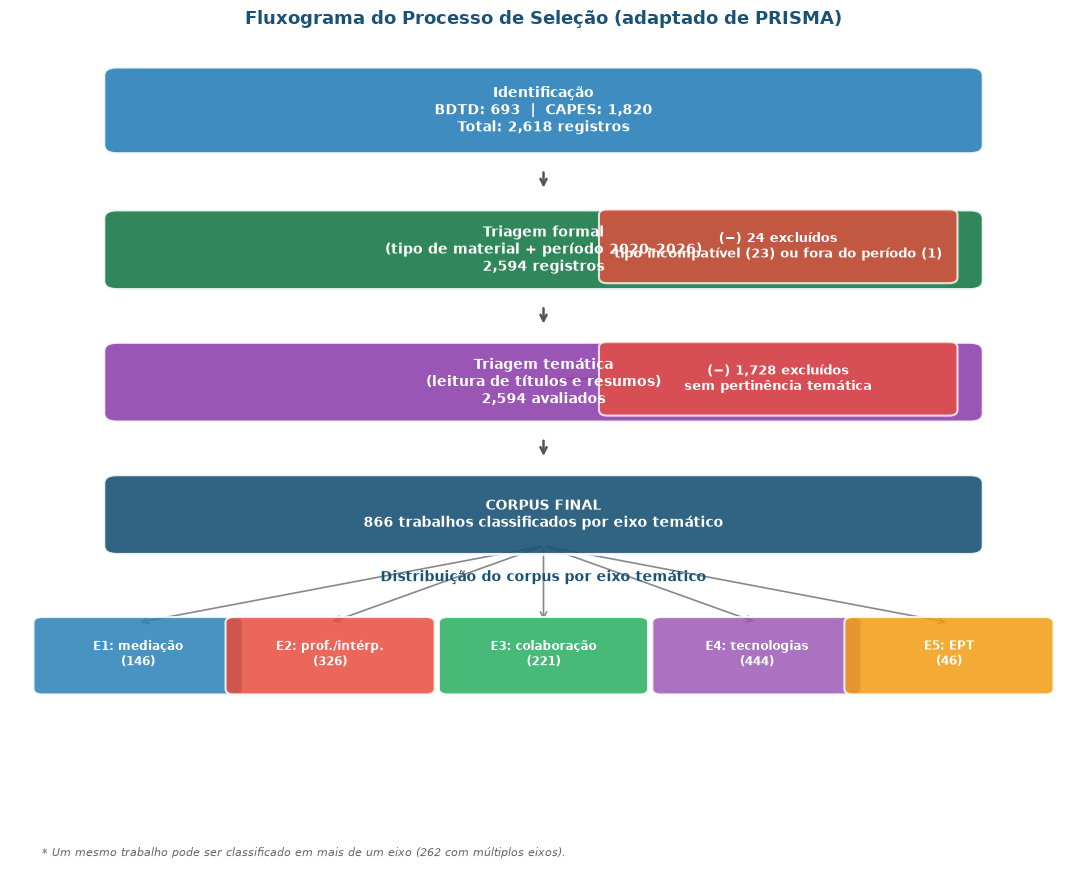

In [4]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Fluxograma do Processo de Seleção (adaptado de PRISMA)',
             fontsize=13, fontweight='bold', color=ACCENT, pad=12)

def box(ax, x, y, w, h, text, color, fontsize=10):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.12", facecolor=color,
        edgecolor='white', linewidth=2, alpha=0.90, zorder=3
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color='white', fontweight='bold', zorder=4, wrap=True,
            multialignment='center')

def seta(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2 + 0.35), xytext=(x1, y1 - 0.35),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=2)

def box_excl(ax, x, y, text):
    rect = mpatches.FancyBboxPatch(
        (x, y - 0.4), 3.2, 0.9,
        boxstyle="round,pad=0.08", facecolor='#e74c3c',
        edgecolor='white', linewidth=1.5, alpha=0.80, zorder=3
    )
    ax.add_patch(rect)
    ax.text(x + 1.6, y + 0.05, text, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold', zorder=4)
    ax.annotate('', xy=(x, y + 0.05), xytext=(5, y + 0.05),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5), zorder=2)

# Caixas principais (eixo central x=5)
box(ax, 5, 11,  8, 1.0,
    f'Identificação\nBDTD: {n_bdtd:,}  |  CAPES: {n_capes:,}\nTotal: {total_bruto:,} registros',
    '#2980b9')
seta(ax, 5, 10.5, 5, 9.5)

box(ax, 5, 9,   8, 0.9,
    f'Triagem formal\n(tipo de material + período 2020–2026)\n{n_apos_triagem:,} registros',
    '#1a7a4a')
seta(ax, 5, 8.55, 5, 7.55)

box(ax, 5, 7.1, 8, 0.9,
    f'Triagem temática\n(leitura de títulos e resumos)\n{n_apos_triagem:,} avaliados',
    '#8e44ad')
seta(ax, 5, 6.65, 5, 5.65)

box(ax, 5, 5.2, 8, 0.9,
    f'CORPUS FINAL\n{n_corpus:,} trabalhos classificados por eixo temático',
    ACCENT)

# Caixas de exclusão (direita)
box_excl(ax, 5.6, 9.0,
         f'(−) {n_excluidos_tipo + n_excluidos_periodo:,} excluídos\n'
         f'tipo incompatível ({n_excluidos_tipo}) ou fora do período ({n_excluidos_periodo})')
box_excl(ax, 5.6, 7.1,
         f'(−) {n_excl_tematica:,} excluídos\nsem pertinência temática')

# Decomposição por eixo
y_eixo = 3.8
ax.text(5, y_eixo + 0.5, 'Distribuição do corpus por eixo temático',
        ha='center', va='center', fontsize=10, color=ACCENT, fontweight='bold')
nomes_curtos = ['E1: mediação','E2: prof./intérp.','E3: colaboração','E4: tecnologias','E5: EPT']
ns_eixo = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
xs = [1.2, 3.0, 5.0, 7.0, 8.8]
for xi, nome, ni, cor in zip(xs, nomes_curtos, ns_eixo, PAL):
    rect = mpatches.FancyBboxPatch(
        (xi - 0.9, y_eixo - 1.1), 1.8, 0.95,
        boxstyle="round,pad=0.08", facecolor=cor, edgecolor='white',
        linewidth=1.5, alpha=0.85, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xi, y_eixo - 0.6, f'{nome}\n({ni})', ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold', zorder=4)
    ax.annotate('', xy=(xi, y_eixo - 0.15), xytext=(5, 4.75),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2), zorder=2)

ax.text(0.3, 0.3, f'* Um mesmo trabalho pode ser classificado em mais de um eixo ({multi} com múltiplos eixos).',
        fontsize=8, color='#666', style='italic')

plt.tight_layout()
plt.savefig('data/fig_fluxograma_selecao.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Panorama do Corpus

Caracterização geral dos trabalhos que compõem o corpus final, considerando base de dados de origem, tipo de material, distribuição temporal, região geográfica e instituição de vinculação.


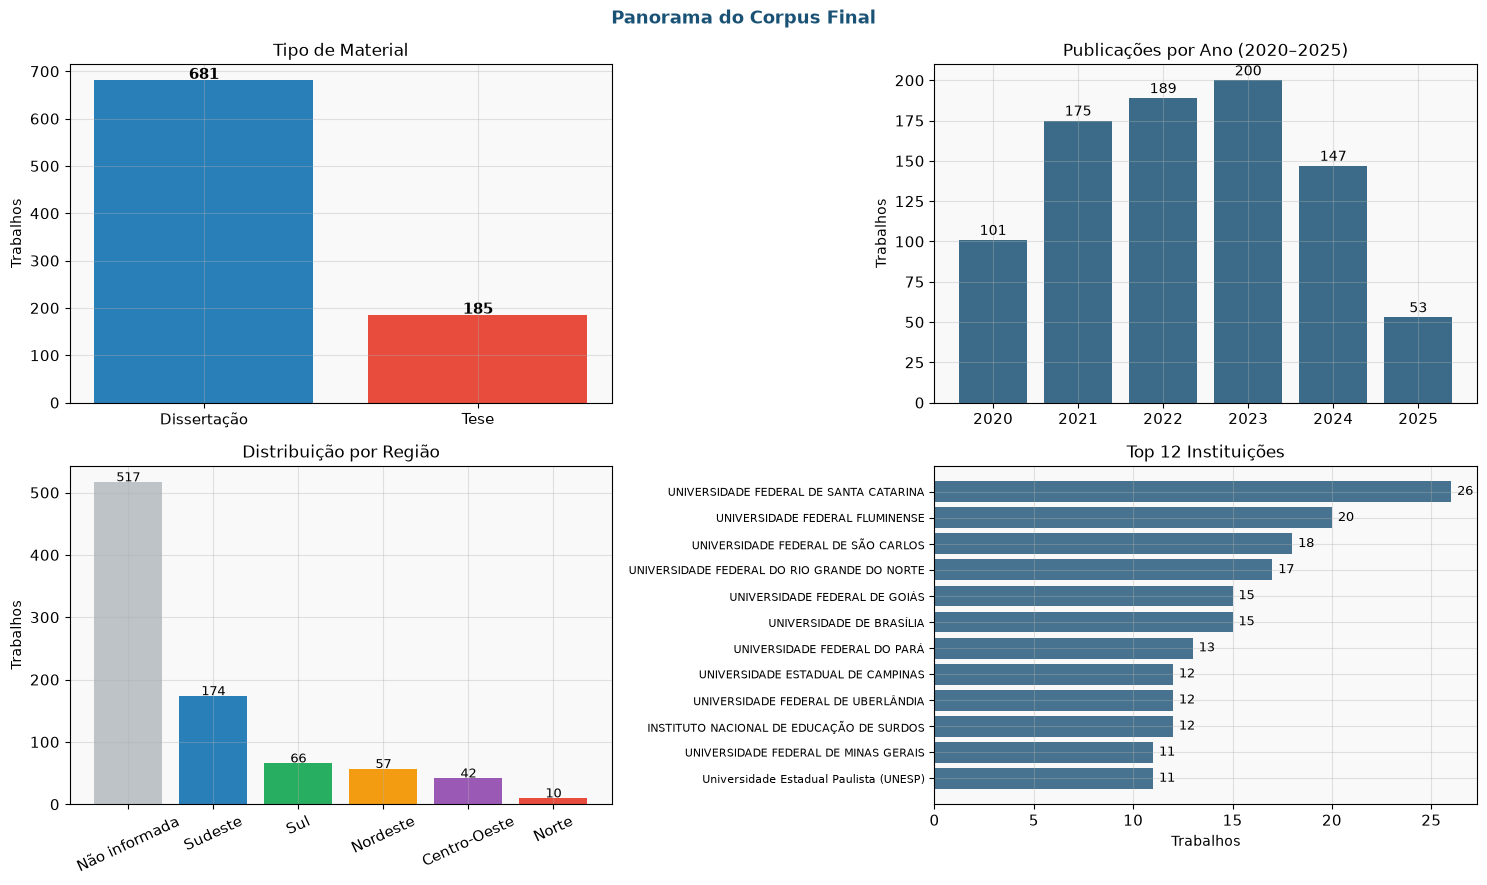

Composição do corpus: 681 dissertações (79%) e 185 teses (21%)
Período com maior concentração: 2023 (200 trabalhos)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Panorama do Corpus Final', fontsize=13, fontweight='bold', color=ACCENT)

# 1. Distribuição por tipo de material
tipo_c = df_corpus['Tipo'].replace('','Não inf.').fillna('Não inf.').value_counts()
tipo_c = tipo_c[tipo_c.index.isin(['Dissertação','Tese'])]
axes[0,0].bar(tipo_c.index, tipo_c.values, color=[PAL[0], PAL[1]])
axes[0,0].set_title('Tipo de Material')
axes[0,0].set_ylabel('Trabalhos')
for i, v in enumerate(tipo_c.values):
    axes[0,0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=11)

# 2. Distribuição anual (2020–2025)
ano_foco = df_corpus[(df_corpus['Ano'] >= 2020) & (df_corpus['Ano'] <= 2025)]
ano_c = ano_foco.groupby('Ano').size()
bars = axes[0,1].bar(ano_c.index, ano_c.values, color=ACCENT, alpha=0.85)
axes[0,1].set_title('Publicações por Ano (2020–2025)')
axes[0,1].set_ylabel('Trabalhos')
axes[0,1].set_xticks(range(2020, 2026))
for bar, v in zip(bars, ano_c.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
                   ha='center', va='bottom', fontsize=10)

# 3. Distribuição regional
reg_c = df_corpus['Região do Brasil'].replace('','Não informada').fillna('Não informada').value_counts()
cores_reg = {'Sudeste':'#2980b9','Sul':'#27ae60','Nordeste':'#f39c12',
             'Centro-Oeste':'#9b59b6','Norte':'#e74c3c','Não informada':'#bdc3c7','Nacional':'#95a5a6'}
cores_r = [cores_reg.get(r,'#bdc3c7') for r in reg_c.index]
axes[1,0].bar(reg_c.index, reg_c.values, color=cores_r)
axes[1,0].set_title('Distribuição por Região')
axes[1,0].set_ylabel('Trabalhos')
axes[1,0].tick_params(axis='x', rotation=25)
for i, v in enumerate(reg_c.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontsize=9)

# 4. Top 12 Instituições
inst_c = df_corpus['Instituição'].replace('','Não inf.').fillna('Não inf.')
inst_c = inst_c[inst_c != 'Não inf.'].value_counts().head(12)
axes[1,1].barh(inst_c.index[::-1], inst_c.values[::-1], color=ACCENT, alpha=0.8)
axes[1,1].set_title('Top 12 Instituições')
axes[1,1].set_xlabel('Trabalhos')
axes[1,1].set_yticklabels([i[:45] for i in inst_c.index[::-1]], fontsize=8)
for i, v in enumerate(inst_c.values[::-1]):
    axes[1,1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/fig_panorama_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

# Síntese textual
diss = (df_corpus['Tipo']=='Dissertação').sum()
tese = (df_corpus['Tipo']=='Tese').sum()
print(f"Composição do corpus: {diss} dissertações ({diss/n_corpus*100:.0f}%) e {tese} teses ({tese/n_corpus*100:.0f}%)")
print(f"Período com maior concentração: {ano_foco.groupby('Ano').size().idxmax()} ({ano_foco.groupby('Ano').size().max()} trabalhos)")


## 4. Análise por Eixo Temático

Cada eixo é analisado quanto à distribuição temporal, tipo de material, sujeitos predominantes, instituições com maior produção, palavras-chave mais recorrentes e contribuição para a compreensão do objeto de pesquisa.

> Os trabalhos classificados em múltiplos eixos são contabilizados em cada eixo pertinente.


In [6]:
import re
from collections import Counter

STOPWORDS = {
    'para','com','uma','que','dos','das','por','nas','nos','não','são','mais',
    'sobre','como','seus','suas','este','esta','esse','essa','entre','pelo',
    'pela','num','sem','ter','ser','foi','seu','sua','isto','isso','também',
    'ainda','quando','onde','qual','todos','cada','muito','sendo','tendo',
    'fazer','feito','neste','nesta','após','antes','desde','até','pois','mas',
    'porém','este','esta','esses','essas','eles','elas','nos','nas','esse',
    'essa','isso','aqui','ali','há','lhe','lhes','seu','seus','sua','suas',
}

def top_kw(subdf, n=10):
    kws = []
    for k in subdf['Palavras-chave'].dropna():
        for t in re.split(r'[,;|]+', str(k)):
            t = t.strip().lower().replace('.','')
            if len(t) > 3 and t not in STOPWORDS and not t.isdigit():
                kws.append(t)
    return Counter(kws).most_common(n)

def analise_eixo(eixo_key):
    titulo = EIXO_FULL[eixo_key]
    sub = df_corpus[df_corpus['Eixo'].str.contains(eixo_key, regex=False, na=False)].copy()
    n = len(sub)

    print("=" * 68)
    print(f"  {titulo}")
    print(f"  {n} trabalhos no corpus")
    print("=" * 68)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(titulo, fontsize=11, fontweight='bold', color=ACCENT, y=1.01)
    cor = PAL[EIXOS.index(eixo_key)]

    # Evolução temporal
    sub_ano = sub[(sub['Ano'] >= 2020) & (sub['Ano'] <= 2025)]
    ano_c = sub_ano.groupby('Ano').size().reindex(range(2020, 2026), fill_value=0)
    axes[0].bar(ano_c.index, ano_c.values, color=cor, alpha=0.85)
    axes[0].set_title('Publicações por Ano (2020–2025)')
    axes[0].set_ylabel('Trabalhos')
    axes[0].set_xticks(range(2020, 2026))
    for x, v in zip(ano_c.index, ano_c.values):
        if v > 0:
            axes[0].text(x, v + 0.3, str(v), ha='center', va='bottom', fontsize=9)

    # Tipo de material
    tipo_c = sub['Tipo'].replace('','Outro').fillna('Outro').value_counts().head(4)
    axes[1].barh(tipo_c.index[::-1], tipo_c.values[::-1], color=cor, alpha=0.85)
    axes[1].set_title('Tipo de Material')
    axes[1].set_xlabel('Trabalhos')
    for i, v in enumerate(tipo_c.values[::-1]):
        axes[1].text(v + 0.3, i, str(v), va='center', fontsize=10)

    # Palavras-chave
    kws = top_kw(sub, 10)
    if kws:
        kw_labels = [k[:35] for k, _ in kws]
        kw_vals = [v for _, v in kws]
        axes[2].barh(kw_labels[::-1], kw_vals[::-1], color=cor, alpha=0.8)
        axes[2].set_title('Palavras-chave mais recorrentes')
        axes[2].set_xlabel('Frequência')
        axes[2].tick_params(axis='y', labelsize=8.5)
    else:
        axes[2].text(0.5, 0.5, 'Sem dados', ha='center', transform=axes[2].transAxes)
        axes[2].axis('off')

    plt.tight_layout()
    fname = f"data/fig_{eixo_key.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    # Estatísticas textuais (sem scores)
    print(f"\nDistribuição por tipo:")
    for t, c in sub['Tipo'].replace('','Outro').fillna('Outro').value_counts().items():
        print(f"  {t}: {c} ({c/n*100:.0f}%)")

    print(f"\nDistribuição por região:")
    reg = sub['Região do Brasil'].replace('','Não informada').fillna('Não informada').value_counts()
    for r, c in reg.head(5).items():
        print(f"  {r}: {c}")

    print(f"\nTop 5 instituições:")
    inst = sub['Instituição'].replace('','').fillna('')
    inst = inst[inst != ''].value_counts().head(5)
    for ins, c in inst.items():
        print(f"  {c}x  {ins[:70]}")

    print(f"\nTop 10 palavras-chave: {[k for k,_ in kws]}")

    # Sujeitos (se preenchidos)
    suj = sub['Sujeitos da Pesquisa'].replace('','').fillna('')
    suj = suj[suj != ''].value_counts().head(5)
    if len(suj):
        print(f"\nSujeitos predominantes:")
        for s, c in suj.items():
            print(f"  {c}x  {s[:80]}")

    print()

print("Função analise_eixo() carregada.")


Função analise_eixo() carregada.


### Eixo 1 — Educação de surdos + mediação

Mapeia a produção que articula **educação de surdos** com processos de **mediação pedagógica e linguística**. Constitui a base teórico-conceitual para compreender como a mediação opera nos contextos educativos investigados, subsidiando o uso das categorias vigotskianas (mediação, zona de desenvolvimento proximal, linguagem como condição do pensamento conceitual) e da Pedagogia Histórico-Crítica (Saviani, 2011) como referenciais centrais da pesquisa.

**Contribuição para a pesquisa:** fornece o embasamento conceitual da mediação pedagógica e linguística como processo intencional de organização do acesso ao saber sistematizado — perspectiva que orienta a compreensão das práticas colaborativas entre professor e intérprete.


  Eixo 1 — Educação de surdos + mediação
  146 trabalhos no corpus


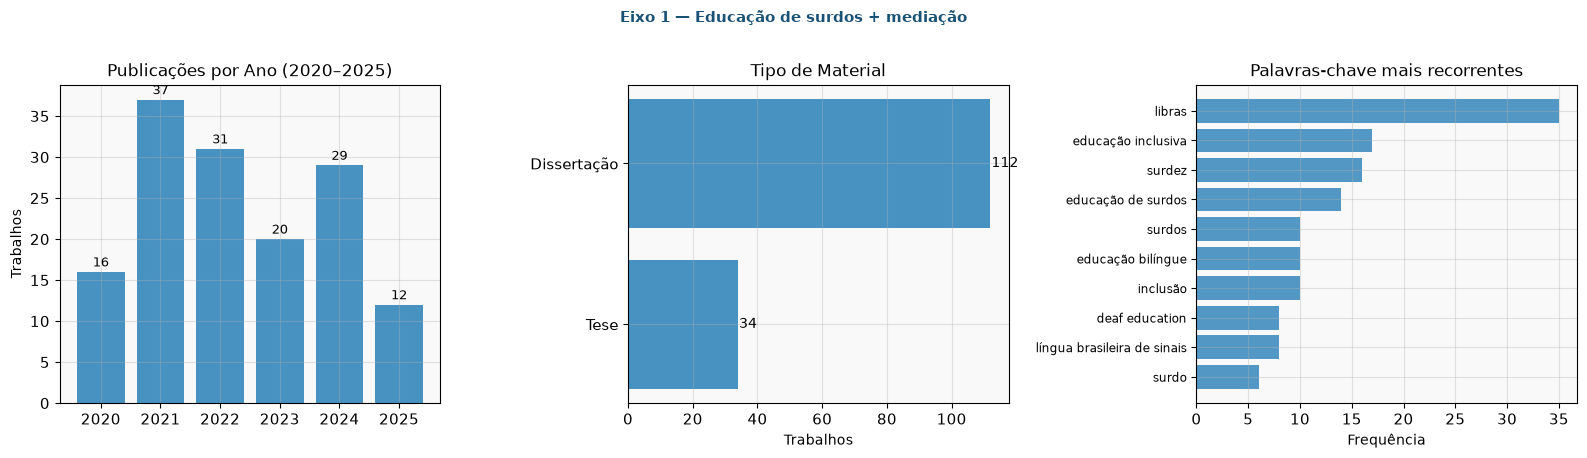


Distribuição por tipo:
  Dissertação: 112 (77%)
  Tese: 34 (23%)

Distribuição por região:
  Não informada: 91
  Sudeste: 28
  Nordeste: 14
  Sul: 12
  Centro-Oeste: 1

Top 5 instituições:
  5x  Universidade Federal de Santa Catarina (UFSC)
  5x  Universidade de São Paulo (USP)
  5x  Universidade Federal de Campina Grande (UFCG)
  4x  Universidade Federal de Pernambuco (UFPE)
  4x  Universidade Federal Fluminense (UFF)

Top 10 palavras-chave: ['libras', 'educação inclusiva', 'surdez', 'educação de surdos', 'surdos', 'educação bilíngue', 'inclusão', 'deaf education', 'língua brasileira de sinais', 'surdo']

Sujeitos predominantes:
  2x  Intérpretes de Libras
  2x  Pessoas Surdas / Comunidade Acadêmica
  1x  Professores e Alunos Surdos e Crianças Surdas
  1x  Professores e Alunos Surdos e Intérpretes de Libras e Familiares e Ouvintes
  1x  Professores e Alunos Surdos e Familiares



In [7]:
analise_eixo('Eixo 1')


### Eixo 2 — Educação de surdos + professor + intérprete *(Eixo Nuclear)*

> **Este é o eixo nuclear da pesquisa.** Mapeia diretamente a relação professor-intérprete em contextos bilíngues, as práticas colaborativas de mediação e os desafios da atuação conjunta — fenômeno central da investigação.

A produção deste eixo documenta como professores e intérpretes organizam (ou não) o trabalho pedagógico conjunto, quais estratégias de mediação são mobilizadas e quais condições institucionais favorecem ou dificultam a colaboração. Os trabalhos de Lacerda (2006), Silva, Coimbra e Nascimento (2023) e demais autores mapeados aqui constituem a **referência empírica mais direta** para os objetivos específicos 1 e 2 da pesquisa.

**Lacuna confirmada pelo eixo:** escassez de investigações sobre práticas colaborativas professor-intérprete especificamente no contexto da **Educação Profissional e Tecnológica** e dos **Institutos Federais**.


  Eixo 2 — Educação de surdos + professor/intérprete
  326 trabalhos no corpus


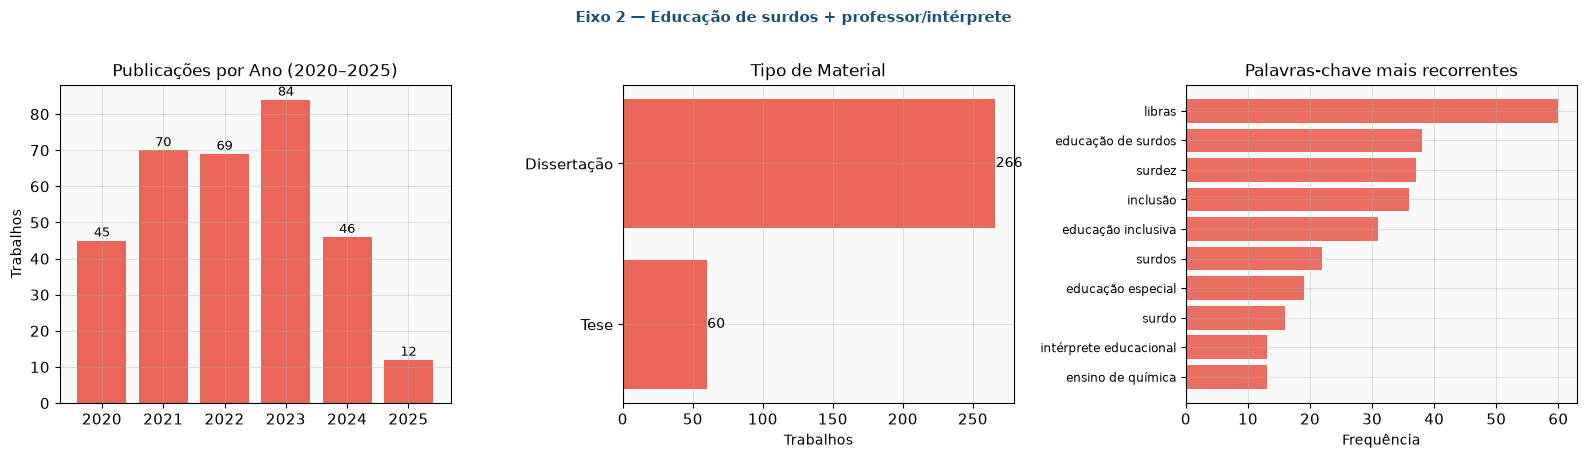


Distribuição por tipo:
  Dissertação: 266 (82%)
  Tese: 60 (18%)

Distribuição por região:
  Não informada: 205
  Sudeste: 69
  Sul: 20
  Centro-Oeste: 15
  Nordeste: 12

Top 5 instituições:
  10x  UNIVERSIDADE FEDERAL FLUMINENSE
  8x  UNIVERSIDADE FEDERAL DE SANTA CATARINA
  8x  UNIVERSIDADE DE BRASÍLIA
  7x  Universidade Federal de Santa Catarina (UFSC)
  7x  UNIVERSIDADE FEDERAL DE SÃO CARLOS

Top 10 palavras-chave: ['libras', 'educação de surdos', 'surdez', 'inclusão', 'educação inclusiva', 'surdos', 'educação especial', 'surdo', 'intérprete educacional', 'ensino de química']

Sujeitos predominantes:
  14x  Professores e Alunos Surdos e Intérpretes de Libras
  8x  Professores e Alunos Surdos e Intérpretes de Libras e Familiares
  3x  Professores e Alunos Surdos e Intérpretes de Libras e Familiares e Ouvintes
  3x  Intérpretes de Libras
  2x  Professores e Alunos Surdos e Intérpretes de Libras e Ouvintes



In [8]:
analise_eixo('Eixo 2')


### Eixo 3 — Educação de surdos + colaboração

Mapeia a produção sobre **trabalho colaborativo**, **codocência** e **coplanejamento** em contextos de educação de surdos. Subsidia a compreensão das formas de organização do trabalho conjunto entre professores e intérpretes, explorando como a colaboração é operacionalizada nas práticas educativas e quais condições a favorecem.

**Contribuição para a pesquisa:** fundamenta o construto de "práticas colaborativas" utilizado na investigação e orienta a elaboração do roteiro de entrevistas e a observação do campo empírico.


  Eixo 3 — Educação de surdos + colaboração
  221 trabalhos no corpus


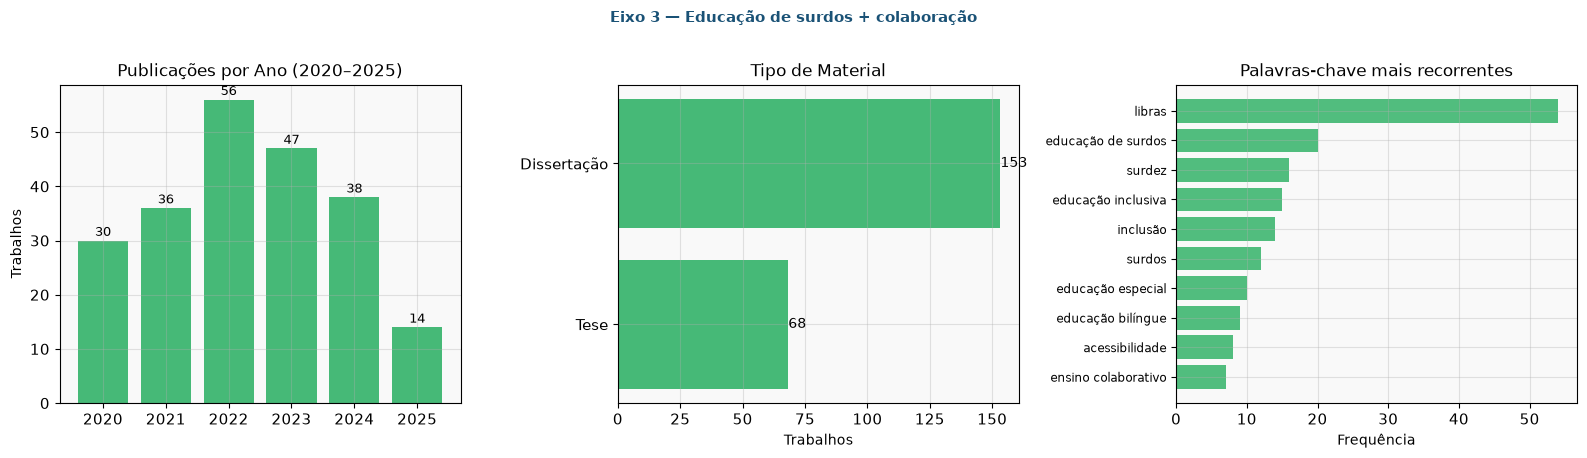


Distribuição por tipo:
  Dissertação: 153 (69%)
  Tese: 68 (31%)

Distribuição por região:
  Não informada: 127
  Sudeste: 43
  Nordeste: 20
  Sul: 16
  Centro-Oeste: 13

Top 5 instituições:
  10x  UNIVERSIDADE FEDERAL DE SANTA CATARINA
  8x  UNIVERSIDADE FEDERAL DE GOIÁS
  7x  UNIVERSIDADE FEDERAL DE SÃO CARLOS
  7x  UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE
  6x  Universidade Estadual Paulista (UNESP)

Top 10 palavras-chave: ['libras', 'educação de surdos', 'surdez', 'educação inclusiva', 'inclusão', 'surdos', 'educação especial', 'educação bilíngue', 'acessibilidade', 'ensino colaborativo']

Sujeitos predominantes:
  1x  Professores e Alunos Surdos e Intérpretes de Libras e Familiares
  1x  Professores e Alunos Surdos e Intérpretes de Libras
  1x  Professores e Intérpretes de Libras e Ouvintes
  1x  Professores e Alunos Surdos
  1x  Alunos Surdos



In [9]:
analise_eixo('Eixo 3')


### Eixo 4 — Educação de surdos + tecnologias

Mapeia a produção sobre **tecnologias educacionais** para estudantes surdos: softwares, aplicativos, plataformas digitais, ambientes de aprendizagem, recursos de acessibilidade e hipermídias bilíngues. Constitui a base empírica para o desenvolvimento do **Produto Educacional** (Ambiente Bilíngue de Mediação Conceitual), permitindo identificar soluções existentes, limitações das abordagens atuais e requisitos relevantes.

**Lacuna confirmada pelo eixo:** a maioria das soluções tecnológicas está focada em tradução automática ou glossários — há escassez de **ambientes digitais colaborativos orientados à mediação conceitual** entre professores e intérpretes em contextos bilíngues.


  Eixo 4 — Educação de surdos + tecnologias
  444 trabalhos no corpus


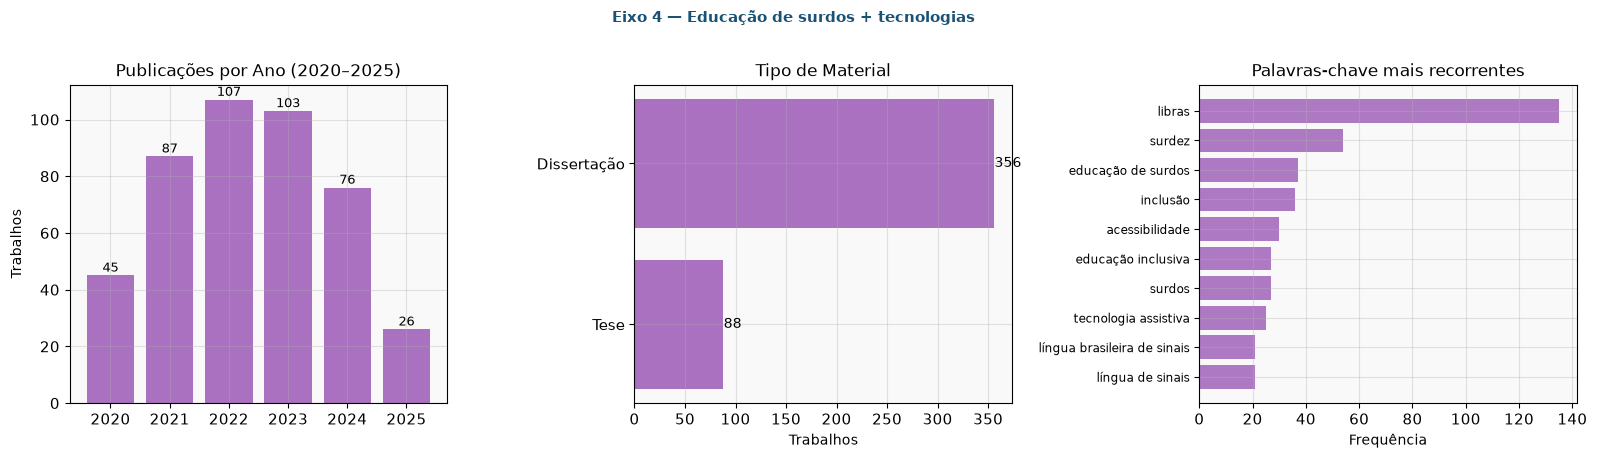


Distribuição por tipo:
  Dissertação: 356 (80%)
  Tese: 88 (20%)

Distribuição por região:
  Não informada: 269
  Sudeste: 84
  Sul: 38
  Nordeste: 26
  Centro-Oeste: 22

Top 5 instituições:
  13x  UNIVERSIDADE FEDERAL DE SANTA CATARINA
  12x  UNIVERSIDADE FEDERAL FLUMINENSE
  11x  UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE
  10x  UNIVERSIDADE DE BRASÍLIA
  10x  UNIVERSIDADE FEDERAL DE SÃO CARLOS

Top 10 palavras-chave: ['libras', 'surdez', 'educação de surdos', 'inclusão', 'acessibilidade', 'educação inclusiva', 'surdos', 'tecnologia assistiva', 'língua brasileira de sinais', 'língua de sinais']

Sujeitos predominantes:
  8x  Pessoas Surdas / Comunidade Acadêmica
  4x  Professores e Alunos Surdos e Intérpretes de Libras
  3x  Intérpretes de Libras
  3x  Alunos Surdos
  3x  Familiares



In [10]:
analise_eixo('Eixo 4')


### Eixo 5 — Educação Profissional e Tecnológica (EPT)

Embora o menor em volume, **este eixo é estrategicamente decisivo**: delimita o estado da arte especificamente no contexto da **EPT e dos Institutos Federais**, campo onde a pesquisa se desenvolve. A baixa produção identificada — em contraste com o volume dos demais eixos — confirma empiricamente a **lacuna científica** que justifica e orienta esta investigação.

Como Silva, Coimbra e Nascimento (2023) constatam, a ausência de parceria efetiva entre professores e intérpretes nos IFs é um dos principais desafios identificados, mas permanece subinvestigada na literatura acadêmica nacional. O estado da arte do Eixo 5 evidencia que o subcampo "TILS + EPT" é emergente, com poucas referências disponíveis para orientar práticas e subsidiar políticas institucionais.


  Eixo 5 — Educação Profissional e Tecnológica
  46 trabalhos no corpus


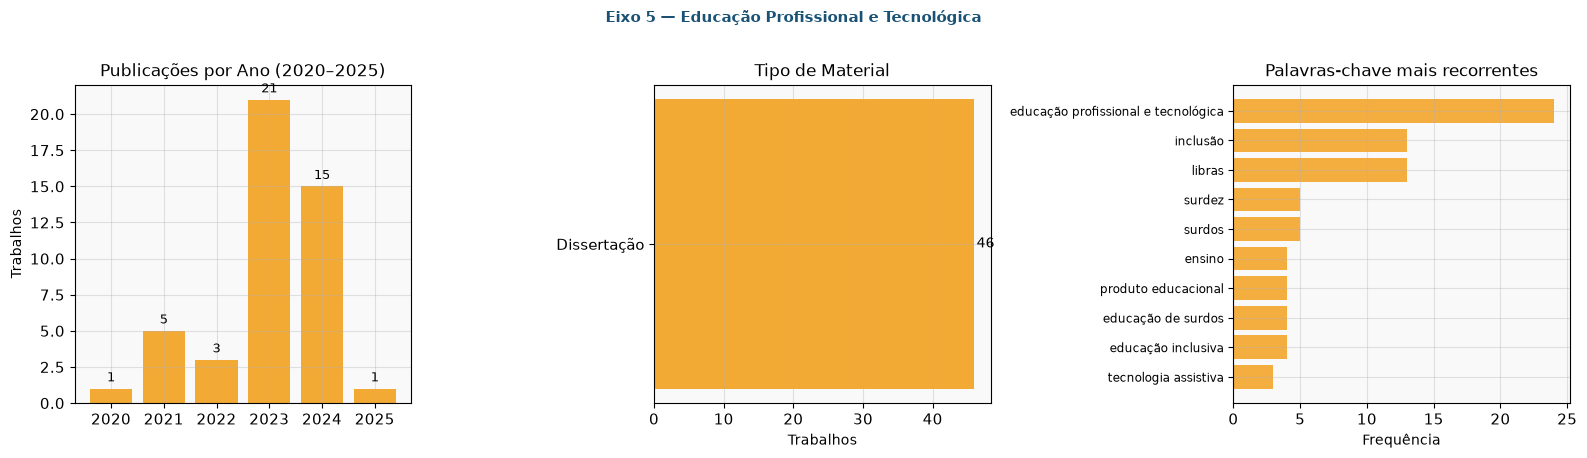


Distribuição por tipo:
  Dissertação: 46 (100%)

Distribuição por região:
  Sudeste: 33
  Não informada: 7
  Nordeste: 3
  Centro-Oeste: 1
  Sul: 1

Top 5 instituições:
  3x  INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO RIO GRANDE DO S
  2x  INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO AMAZONAS
  2x  Instituto Federal de Educação, Ciência e Tecnologia de Pernambuco (IFP
  2x  Instituto Federal de Educação, Ciência e Tecnologia do Espírito Santo 
  2x  INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DE RORAIMA

Top 10 palavras-chave: ['educação profissional e tecnológica', 'inclusão', 'libras', 'surdez', 'surdos', 'ensino', 'produto educacional', 'educação de surdos', 'educação inclusiva', 'tecnologia assistiva']

Sujeitos predominantes:
  1x  Professores e Alunos Surdos e Intérpretes de Libras e Familiares
  1x  Alunos Surdos
  1x  Professores e Alunos Surdos e Intérpretes de Libras
  1x  Estudantes e egressos do curso de Tradutor/Intérprete de Libras-Português

In [11]:
analise_eixo('Eixo 5')


## 5. Visão Cruzada dos Eixos

Mapa de calor da cobertura temporal e análise dos trabalhos classificados em múltiplos eixos, que representam maior integração temática com o objeto da pesquisa.


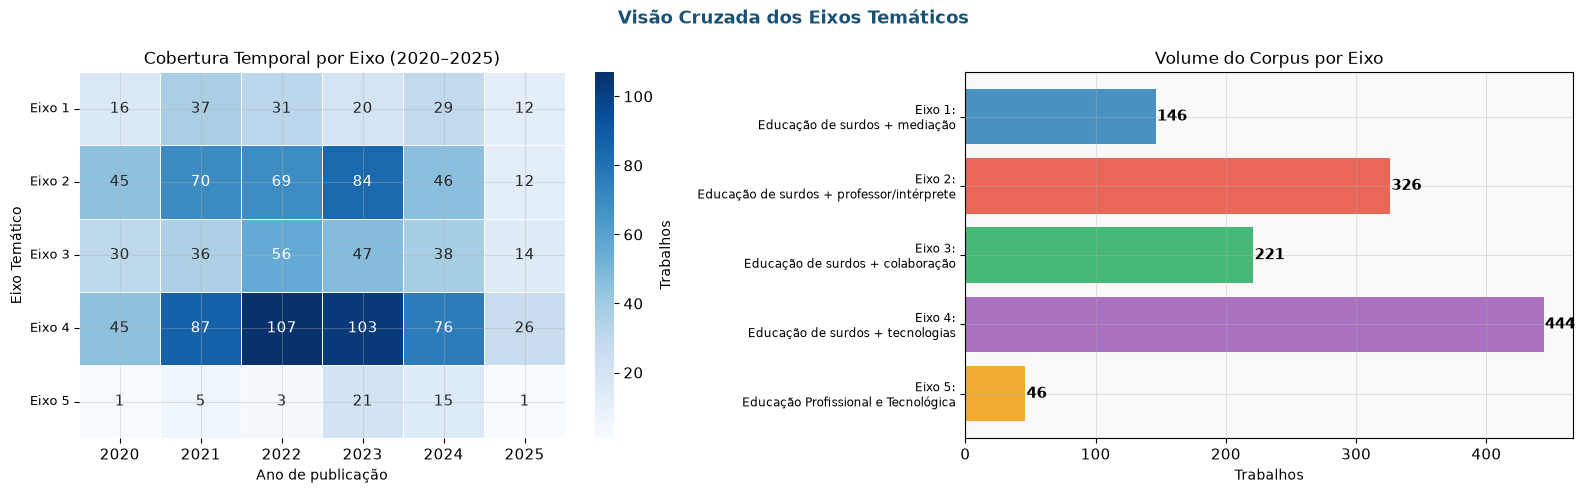


TRABALHOS EM MÚLTIPLOS EIXOS (integração temática mais ampla)
Total: 262 trabalhos em ≥ 2 eixos | 50 em ≥ 3 eixos

[4 eixos] (2022) Práticas inclusivas: análise da formação e atuação do professor intérprete de Libras
  OLIVEIRA NETO, Artur Maciel
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2022) Análise das percepções de licenciandos em Biologia, Física e Química da UFV sobre a Educaç
  Bozzi, Raquel Alves
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2022) Práticas inclusivas: análise da formação e atuação do professor intérprete de Libras
  Oliveira Neto, Artur Maciel
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2024) Inclusão de alunos surdos na educação profissional e tecnológica: a comunicação 

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Visão Cruzada dos Eixos Temáticos', fontsize=13, fontweight='bold', color=ACCENT)

# Mapa de calor Eixo × Ano
df_foco = df_corpus[(df_corpus['Ano'] >= 2020) & (df_corpus['Ano'] <= 2025)].copy()
heat_data = {}
for e in EIXOS:
    heat_data[e] = {}
    for ano in range(2020, 2026):
        mask = (df_foco['Eixo'].str.contains(e, regex=False, na=False)) & (df_foco['Ano'] == ano)
        heat_data[e][ano] = mask.sum()

heat_df = pd.DataFrame(heat_data).T
sns.heatmap(heat_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Trabalhos'})
axes[0].set_title('Cobertura Temporal por Eixo (2020–2025)')
axes[0].set_ylabel('Eixo Temático')
axes[0].set_xlabel('Ano de publicação')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# Volume por eixo (barras horizontais)
ns_eixo = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
nomes = [EIXO_FULL[e].replace(' — ', ':\n') for e in EIXOS]
axes[1].barh(nomes[::-1], ns_eixo[::-1], color=PAL[:5][::-1], alpha=0.85)
axes[1].set_title('Volume do Corpus por Eixo')
axes[1].set_xlabel('Trabalhos')
for i, v in enumerate(ns_eixo[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold', fontsize=11)
axes[1].tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.savefig('data/fig_visao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()

# Trabalhos em múltiplos eixos
print("\nTRABALHOS EM MÚLTIPLOS EIXOS (integração temática mais ampla)")
print("=" * 65)
multi_df = df_corpus[df_corpus['Eixo'].str.contains('|', regex=False, na=False)].copy()
multi_df['n_eixos'] = multi_df['Eixo'].str.count('\\|') + 1
print(f"Total: {len(multi_df)} trabalhos em ≥ 2 eixos | "
      f"{len(multi_df[multi_df['n_eixos']>=3])} em ≥ 3 eixos\n")

top_multi = multi_df.nlargest(10, 'n_eixos')[['Título','Autor(es)','Ano','n_eixos','Eixo']]
for _, row in top_multi.iterrows():
    ano = int(row['Ano']) if pd.notna(row['Ano']) else '?'
    print(f"[{int(row['n_eixos'])} eixos] ({ano}) {str(row['Título'])[:90]}")
    print(f"  {str(row['Autor(es)'])[:65]}")
    print(f"  Eixos: {str(row['Eixo'])[:120]}")
    print()


## 6. Lacunas Identificadas no Estado da Arte

A análise do corpus por eixo permite mapear as **lacunas científicas** que fundamentam e orientam esta pesquisa, entendidas como zonas de silêncio ou de investigação insuficiente na produção acadêmica levantada.


SÍNTESE DAS LACUNAS IDENTIFICADAS

Eixo 1 (mediação) (146 trabalhos):
  → Escassez de estudos que articulem mediação pedagógica E linguística de
    forma integrada no contexto bilíngue. A produção tende a tratar as duas
    dimensões de forma separada.

Eixo 2 (prof./intérp.) (326 trabalhos):
  → Poucos estudos investigam especificamente as PRÁTICAS COLABORATIVAS entre
    professor e intérprete na EPT/Institutos Federais. A maioria aborda a
    Educação Básica regular.

Eixo 3 (colaboração) (221 trabalhos):
  → Carência de estudos sobre coplanejamento sistemático e organização
    compartilhada de referências conceituais entre professor e intérprete como
    unidade de análise.

Eixo 4 (tecnologias) (444 trabalhos):
  → A produção está concentrada em tradução automática e glossários de Libras.
    Há escassez de ambientes digitais voltados à MEDIAÇÃO CONCEITUAL bilíngue
    colaborativa.

Eixo 5 (EPT) (46 trabalhos):
  → Volume muito reduzido de produção sobre surdos/TILS especificam

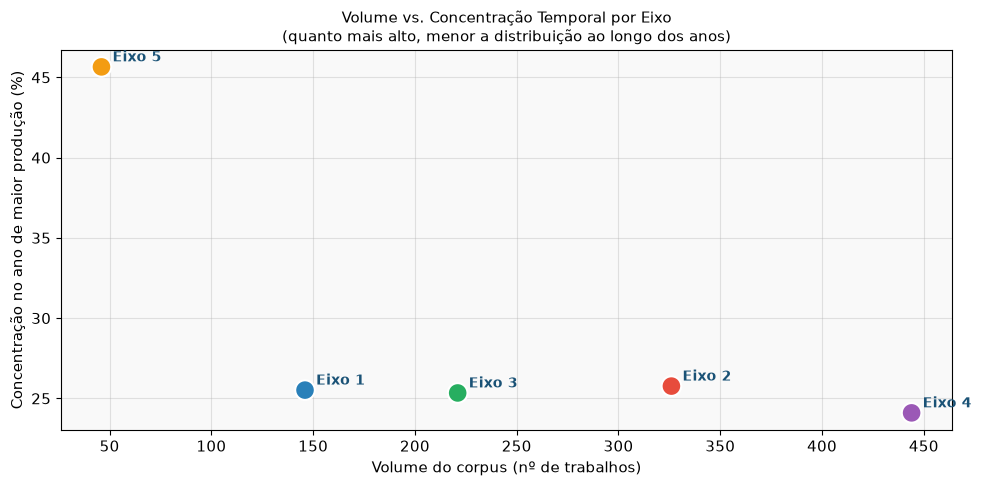

In [13]:
LACUNAS = {
    'Eixo 1\n(mediação)': (
        "Escassez de estudos que articulem mediação pedagógica E linguística de forma integrada "
        "no contexto bilíngue. A produção tende a tratar as duas dimensões de forma separada."
    ),
    'Eixo 2\n(prof./intérp.)': (
        "Poucos estudos investigam especificamente as PRÁTICAS COLABORATIVAS entre professor e "
        "intérprete na EPT/Institutos Federais. A maioria aborda a Educação Básica regular."
    ),
    'Eixo 3\n(colaboração)': (
        "Carência de estudos sobre coplanejamento sistemático e organização compartilhada de "
        "referências conceituais entre professor e intérprete como unidade de análise."
    ),
    'Eixo 4\n(tecnologias)': (
        "A produção está concentrada em tradução automática e glossários de Libras. "
        "Há escassez de ambientes digitais voltados à MEDIAÇÃO CONCEITUAL bilíngue colaborativa."
    ),
    'Eixo 5\n(EPT)': (
        "Volume muito reduzido de produção sobre surdos/TILS especificamente nos Institutos "
        "Federais. Subcampo emergente, com poucas referências para orientar práticas institucionais."
    ),
}

print("SÍNTESE DAS LACUNAS IDENTIFICADAS")
print("=" * 65)
for eixo, lacuna in LACUNAS.items():
    n = df_corpus['Eixo'].str.contains(eixo.split('\n')[0], regex=False, na=False).sum()
    print(f"\n{eixo.replace(chr(10),' ')} ({n} trabalhos):")
    # Quebrar texto
    palavras = lacuna.split()
    linha, linhas = "", []
    for p in palavras:
        if len(linha) + len(p) + 1 > 75:
            linhas.append(linha)
            linha = p
        else:
            linha = (linha + " " + p).strip()
    if linha: linhas.append(linha)
    print("  → " + "\n    ".join(linhas))

# Gráfico de lacunas — volume × concentração temporal
fig, ax = plt.subplots(figsize=(10, 5))
ns   = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
# % concentrado no eixo com maior produção em apenas 1 ano
def concentracao(e):
    s = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    s = s[(s['Ano'] >= 2020) & (s['Ano'] <= 2025)]
    if len(s) == 0: return 0
    return s.groupby('Ano').size().max() / len(s) * 100

conc = [concentracao(e) for e in EIXOS]
scatter = ax.scatter(ns, conc, s=200, c=PAL[:5], zorder=5, edgecolors='white', linewidth=1.5)
for e, n, c in zip(EIXOS, ns, conc):
    ax.annotate(e, (n, c), textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold', color=ACCENT)
ax.set_xlabel('Volume do corpus (nº de trabalhos)', fontsize=11)
ax.set_ylabel('Concentração no ano de maior produção (%)', fontsize=11)
ax.set_title('Volume vs. Concentração Temporal por Eixo\n'
             '(quanto mais alto, menor a distribuição ao longo dos anos)', fontsize=11)
plt.tight_layout()
plt.savefig('data/fig_lacunas.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Síntese do Estado da Arte


In [14]:
# Tabela síntese — sem scores, apenas dados bibliométricos e analíticos
dados_sintese = []
for e in EIXOS:
    sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    n = len(sub)
    diss = (sub['Tipo']=='Dissertação').sum()
    tese = (sub['Tipo']=='Tese').sum()
    ano_sub = sub[(sub['Ano']>=2020)&(sub['Ano']<=2025)]
    ano_pico = int(ano_sub.groupby('Ano').size().idxmax()) if len(ano_sub) else '-'
    dados_sintese.append({
        'Eixo': e,
        'Trabalhos': n,
        'Diss.': diss,
        'Teses': tese,
        'Ano pico': ano_pico,
        'Multi-eixo': sub['Eixo'].str.contains('|', regex=False, na=False).sum(),
    })

df_sint = pd.DataFrame(dados_sintese)
print("TABELA SÍNTESE DO CORPUS POR EIXO TEMÁTICO")
print("=" * 62)
print(df_sint.to_string(index=False))
print()

# Alinhamento com os objetivos específicos
print()
print("RELAÇÃO ENTRE EIXOS E OBJETIVOS ESPECÍFICOS DA PESQUISA")
print("=" * 62)
objs = [
    ("Obj. Esp. 1",
     "Caracterizar práticas colaborativas professor-intérprete na EPT",
     "Eixo 2 (núcleo) + Eixo 3",
     f"{df_corpus['Eixo'].str.contains('Eixo 2', na=False).sum() + df_corpus['Eixo'].str.contains('Eixo 3', na=False).sum()} trabalhos; lacuna: práticas específicas na EPT/IF"),
    ("Obj. Esp. 2",
     "Identificar desafios e necessidades na relação professor-intérprete",
     "Eixo 2 + Eixo 1",
     f"{df_corpus['Eixo'].str.contains('Eixo 2', na=False).sum()} trabalhos; base em Lacerda (2006), Silva et al. (2023)"),
    ("Obj. Esp. 3",
     "Desenvolver o Ambiente Bilíngue de Mediação Conceitual (PE)",
     "Eixo 4 + Eixo 3",
     f"{df_corpus['Eixo'].str.contains('Eixo 4', na=False).sum()} trabalhos; lacuna: ambientes bilíngues de mediação conceitual"),
    ("Obj. Esp. 4",
     "Compreender potencialidades e limites do PE",
     "Eixo 4 + Eixo 5",
     f"{df_corpus['Eixo'].str.contains('Eixo 5', na=False).sum()} trabalhos; subcampo emergente na EPT"),
]
for cod, obj, eixos_rel, nota in objs:
    print(f"\n{cod}: {obj}")
    print(f"  Eixos relacionados: {eixos_rel}")
    print(f"  Nota: {nota}")


TABELA SÍNTESE DO CORPUS POR EIXO TEMÁTICO
  Eixo  Trabalhos  Diss.  Teses  Ano pico  Multi-eixo
Eixo 1        146    112     34      2021          84
Eixo 2        326    266     60      2023         179
Eixo 3        221    153     68      2022         123
Eixo 4        444    356     88      2022         163
Eixo 5         46     46      0      2023          30


RELAÇÃO ENTRE EIXOS E OBJETIVOS ESPECÍFICOS DA PESQUISA

Obj. Esp. 1: Caracterizar práticas colaborativas professor-intérprete na EPT
  Eixos relacionados: Eixo 2 (núcleo) + Eixo 3
  Nota: 547 trabalhos; lacuna: práticas específicas na EPT/IF

Obj. Esp. 2: Identificar desafios e necessidades na relação professor-intérprete
  Eixos relacionados: Eixo 2 + Eixo 1
  Nota: 326 trabalhos; base em Lacerda (2006), Silva et al. (2023)

Obj. Esp. 3: Desenvolver o Ambiente Bilíngue de Mediação Conceitual (PE)
  Eixos relacionados: Eixo 4 + Eixo 3
  Nota: 444 trabalhos; lacuna: ambientes bilíngues de mediação conceitual

Obj. Esp. 4: C

## 8. Considerações Finais

O levantamento bibliográfico realizado — com protocolo sistemático de busca, critérios explícitos de inclusão e exclusão e triagem temática por leitura de títulos e resumos — resultou em um corpus de **866 teses e dissertações**, distribuídas em cinco eixos temáticos que estruturam o estado da arte desta pesquisa.

### O que o estado da arte revela

**1. Produção consolidada, mas com assimetrias:**
Os Eixos 2 (professor/intérprete) e 4 (tecnologias) concentram o maior volume de trabalhos, indicando que a relação professor-intérprete e o uso de tecnologias para surdos são temas já estabelecidos na Pós-Graduação brasileira. Os Eixos 1 (mediação) e 3 (colaboração) apresentam produção intermediária, enquanto o Eixo 5 (EPT) revela produção ainda incipiente.

**2. Lacuna central confirmada:**
A articulação entre *práticas colaborativas professor-intérprete* + *contexto da EPT/Institutos Federais* + *ambiente digital de mediação conceitual bilíngue* não encontra correspondente direto no corpus levantado, confirmando a **originalidade e relevância** do problema de pesquisa formulado.

**3. Pertinência do referencial teórico:**
A produção dos Eixos 1 e 2 valida o diálogo com Vigotski (2009), Saviani (2011) e Lacerda (2006), autores recorrentemente mobilizados nos trabalhos mais próximos ao objeto desta investigação.

**4. Fundamentação do Produto Educacional:**
O Eixo 4 documenta soluções tecnológicas existentes, identificando a predominância de abordagens focadas em tradução e a ausência de ambientes colaborativos voltados à mediação conceitual — lacuna que fundamenta a proposição do Ambiente Bilíngue de Mediação Conceitual (Português/Libras).

---

*Notebook gerado a partir do banco de dados de pesquisa (`data/data.sqlite`).*
*Os dados são carregados diretamente do banco, garantindo reprodutibilidade e atualização automática.*

**Referência:** QUEIROZ, Marco Antônio. *Repositório de apoio à pesquisa*. GitHub, 2026.


[https://marcoantonioq.github.io/profept/arte/]
